In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [9]:
import pandas as pd

dataset = pd.read_csv("/home/ip/Downloads/spam.csv", encoding="latin-1")

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [11]:
dataset.info

<bound method DataFrame.info of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN

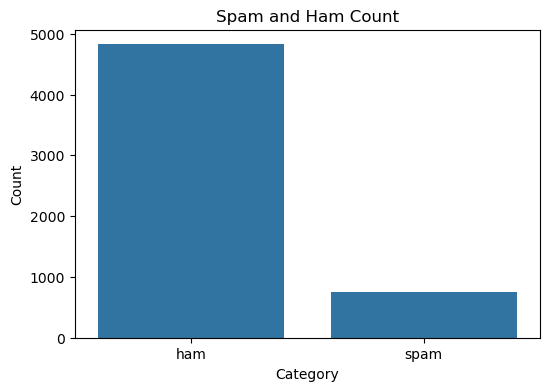

In [15]:
X = dataset['v2'].values
Y = dataset['v1'].values

plt.figure(figsize=(6,4))
sns.countplot(data=dataset, x='v1')

plt.title("Spam and Ham Count")
plt.xlabel("Category")
plt.ylabel("Count")

plt.savefig("exercise3a.png")
plt.show()

In [19]:
dataset = dataset[['v1', 'v2']]
dataset = dataset.dropna()

In [22]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, 
    Y, 
    test_size=0.2,       # 20% data for testing
    random_state=42     # ensures same split every time
)

# Display sizes
print("Training data size:", len(X_train))
print("Testing data size:", len(X_test))

Training data size: 4457
Testing data size: 1115


In [23]:
from sklearn.feature_extraction.text import CountVectorizer

# Create CountVectorizer object
cv = CountVectorizer()

# Fit on training data and transform
X_train_count = cv.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_count = cv.transform(X_test)

# Display the shape of converted data
print("Training data shape:", X_train_count.shape)
print("Testing data shape:", X_test_count.shape)

Training data shape: (4457, 7735)
Testing data shape: (1115, 7735)


In [24]:
from sklearn.svm import SVC

# Create SVM model
svm_model = SVC(kernel='linear')

# Train the model
svm_model.fit(X_train_count, Y_train)

print("SVM model training completed")

SVM model training completed


In [25]:
from sklearn.metrics import accuracy_score

# Predict test data
Y_pred = svm_model.predict(X_test_count)

# Calculate accuracy
accuracy = accuracy_score(Y_test, Y_pred)

print("SVM Accuracy:", accuracy)

SVM Accuracy: 0.979372197309417
